In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
parts_data = pd.read_csv('/content/drive/MyDrive/ML dataset metal/dataset.csv')
print(parts_data.head())
print(parts_data.shape)

   Lifespan partType microstructure  coolingRate  quenchTime  forgeTime  \
0   1107.81    Valve    singleGrain           27        2.64       8.08   
1   1226.13    Valve       colGrain           24        4.06       1.11   
2   1914.12    Blade    singleGrain           20        4.36       8.54   
3   1240.83    Valve    singleGrain           14        3.59       8.83   
4   1599.40   Nozzle    singleGrain           22        3.06       3.04   

   HeatTreatTime  Nickel%  Iron%  Cobalt%  Chromium%  smallDefects  \
0          23.35    60.65  19.76    15.18       4.41             7   
1          24.98    52.47  31.63    12.32       3.58            30   
2          34.71    60.98  26.56    11.60       0.86            22   
3          21.61    54.13  26.71    17.81       1.35            10   
4          29.65    62.88  24.06    12.08       0.98            21   

   largeDefects  sliverDefects seedLocation    castType  
0             0              0          Top  Investment  
1           

In [ ]:
print(parts_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Lifespan        1000 non-null   float64
 1   partType        1000 non-null   object 
 2   microstructure  1000 non-null   object 
 3   coolingRate     1000 non-null   int64  
 4   quenchTime      1000 non-null   float64
 5   forgeTime       1000 non-null   float64
 6   HeatTreatTime   1000 non-null   float64
 7   Nickel%         1000 non-null   float64
 8   Iron%           1000 non-null   float64
 9   Cobalt%         1000 non-null   float64
 10  Chromium%       1000 non-null   float64
 11  smallDefects    1000 non-null   int64  
 12  largeDefects    1000 non-null   int64  
 13  sliverDefects   1000 non-null   int64  
 14  seedLocation    1000 non-null   object 
 15  castType        1000 non-null   object 
dtypes: float64(8), int64(4), object(4)
memory usage: 125.1+ KB
None


In [ ]:
print(parts_data.describe())

          Lifespan  coolingRate   quenchTime    forgeTime  HeatTreatTime  \
count  1000.000000  1000.000000  1000.000000  1000.000000    1000.000000   
mean   1281.806120    17.615000     2.693310     5.487040      30.759280   
std     341.136845     7.480156     1.303057     2.604827      17.054664   
min     359.710000     5.000000     0.510000     1.010000       1.050000   
25%    1039.690000    11.000000     1.540000     3.190000      16.387500   
50%    1254.995000    18.000000     2.625000     5.645000      31.560000   
75%    1539.062500    24.000000     3.822500     7.680000      45.655000   
max    2046.410000    30.000000     5.000000     9.970000      59.990000   

           Nickel%        Iron%      Cobalt%    Chromium%  smallDefects  \
count  1000.000000  1000.000000  1000.000000  1000.000000   1000.000000   
mean     59.646440    25.173290    12.416280     2.763990     16.659000   
std       5.745955     7.312363     4.222616     1.307658     11.885874   
min      50.010

**Univariate Analysis(for numerical features)**

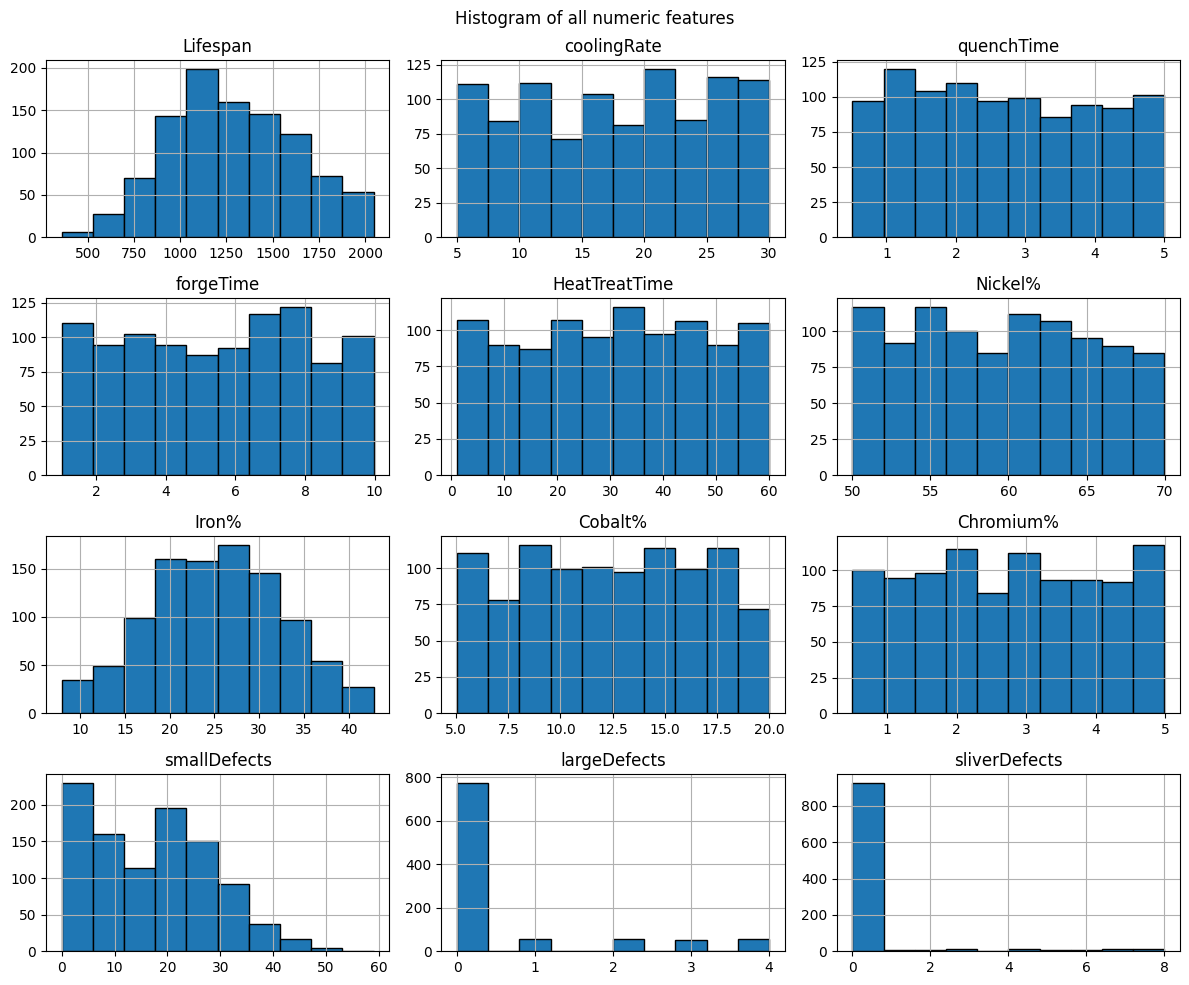

In [ ]:
numerical_features=['Lifespan','coolingRate','quenchTime','forgeTime','HeatTreatTime','Nickel%','Iron%','Cobalt%','Chromium%','smallDefects','largeDefects','sliverDefects']
parts_data[numerical_features].hist(figsize=(12,10),edgecolor='black')
plt.suptitle('Histogram of all numeric features')
plt.tight_layout()
plt.show()


In [ ]:
print(parts_data['Lifespan'].skew())

0.09993262502252453


In [ ]:
parts_data['smallDefects_sqrt']=np.sqrt(parts_data['smallDefects'])
parts_data['smallDefects_cbrt']=np.cbrt(parts_data['smallDefects'])
parts_data['largeDefects_sqrt']=np.sqrt(parts_data['largeDefects'])
parts_data['largeDefects_cbrt']=np.cbrt(parts_data['largeDefects'])
parts_data['sliverDefects_sqrt']=np.sqrt(parts_data['sliverDefects'])
parts_data['sliverDefects_cbrt']=np.cbrt(parts_data['sliverDefects'])

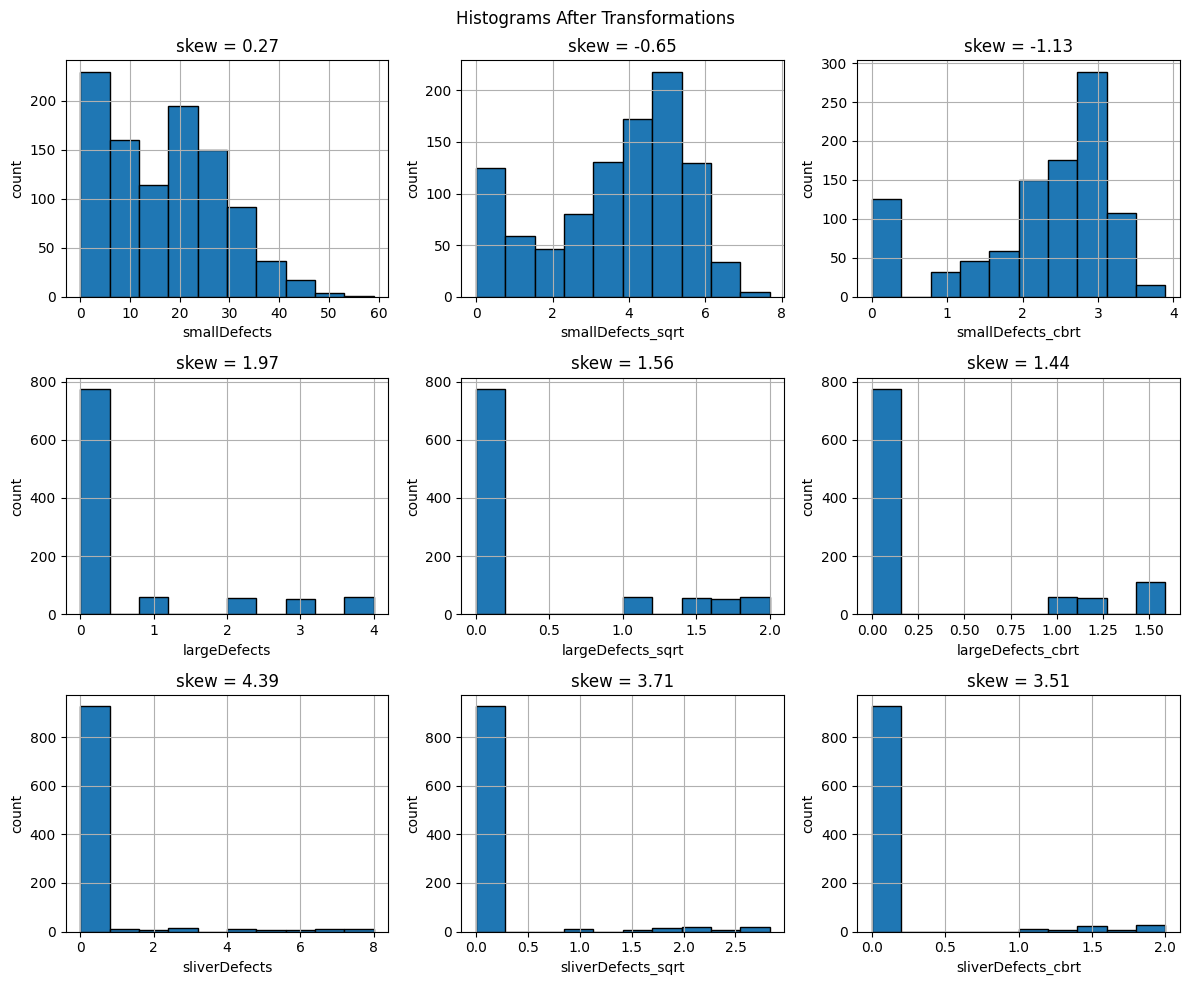

In [ ]:
#log transformation cannot be applied if there are zero values
skewed_features= ['smallDefects','smallDefects_sqrt','smallDefects_cbrt','largeDefects','largeDefects_sqrt','largeDefects_cbrt','sliverDefects','sliverDefects_sqrt','sliverDefects_cbrt']
axes = parts_data[skewed_features].hist(figsize=(12, 10), edgecolor='black')
axes = axes.flatten()
for ax, feature in zip(axes, skewed_features):
    skew_val = parts_data[feature].skew()
    ax.set_xlabel(feature)
    ax.set_ylabel("count")
    ax.set_title(f"skew = {skew_val:.2f}")
plt.suptitle("Histograms After Transformations")
plt.tight_layout()
plt.show()

In [ ]:
parts_data['haslargeDefects']=(parts_data['largeDefects']>0).astype(int)
parts_data['hassliverDefects']=(parts_data['sliverDefects']>0).astype(int)

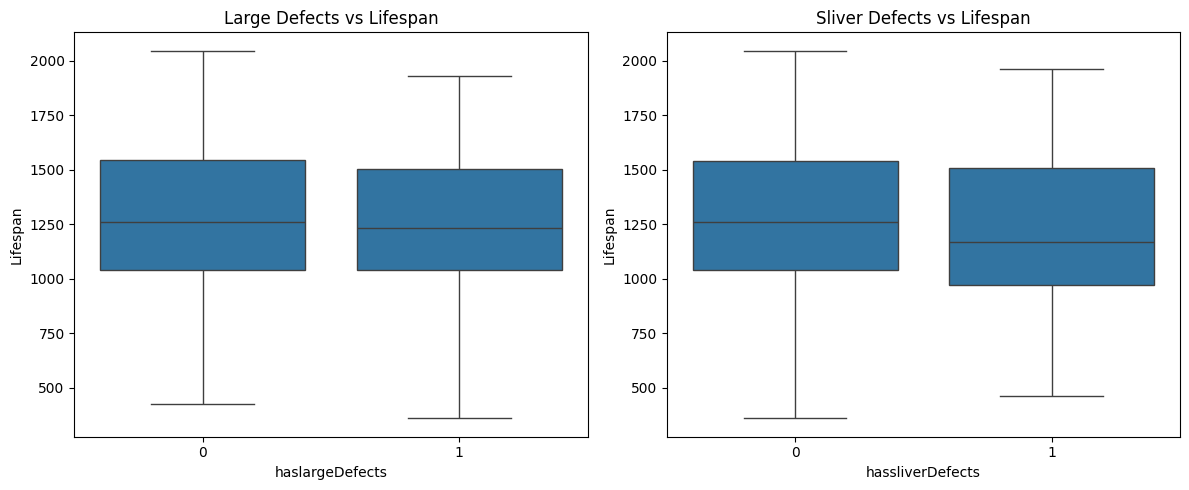

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=parts_data, x='haslargeDefects', y='Lifespan', ax=axes[0])
axes[0].set_title("Large Defects vs Lifespan")

sns.boxplot(data=parts_data, x='hassliverDefects', y='Lifespan', ax=axes[1])
axes[1].set_title("Sliver Defects vs Lifespan")

plt.tight_layout()
plt.show()

**Univariate Analysis(for categorical features)**

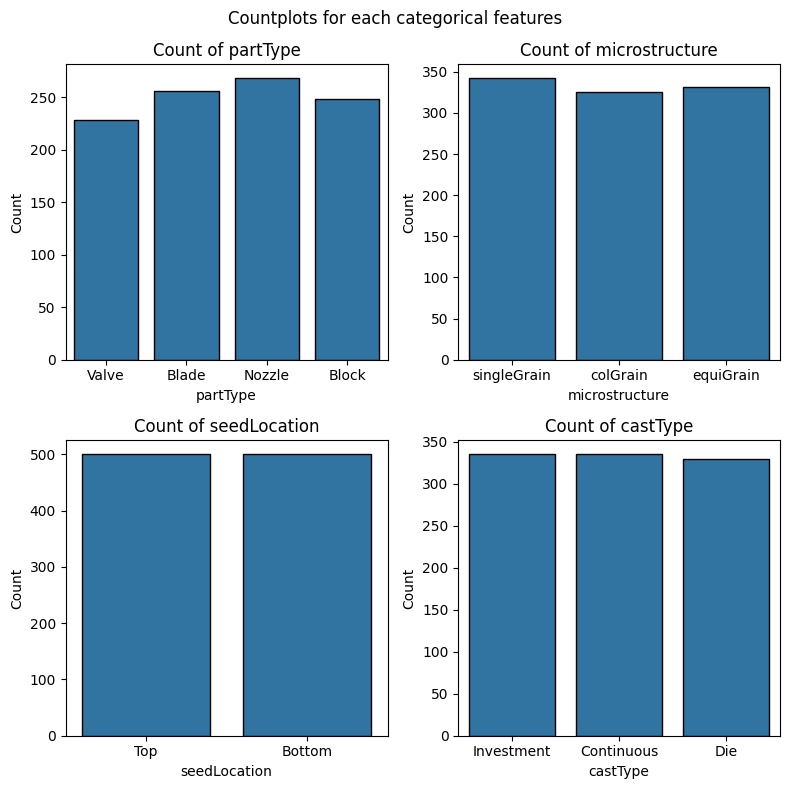

In [ ]:
categorical_features= ['partType','microstructure','seedLocation','castType']
fig, axes=  plt.subplots(2,2, figsize=(8,8))
axes= axes.flatten()
for i, feature in enumerate(categorical_features):
  sns.countplot(data= parts_data,x= feature,ax= axes[i],edgecolor= 'black')
  axes[i].set_title(f"Count of {feature}")
  axes[i].set_xlabel(feature)
  axes[i].set_ylabel("Count")
plt.suptitle("Countplots for each categorical features")
plt.tight_layout()
plt.show()

**Bivariate Analysis(for numerical features)**

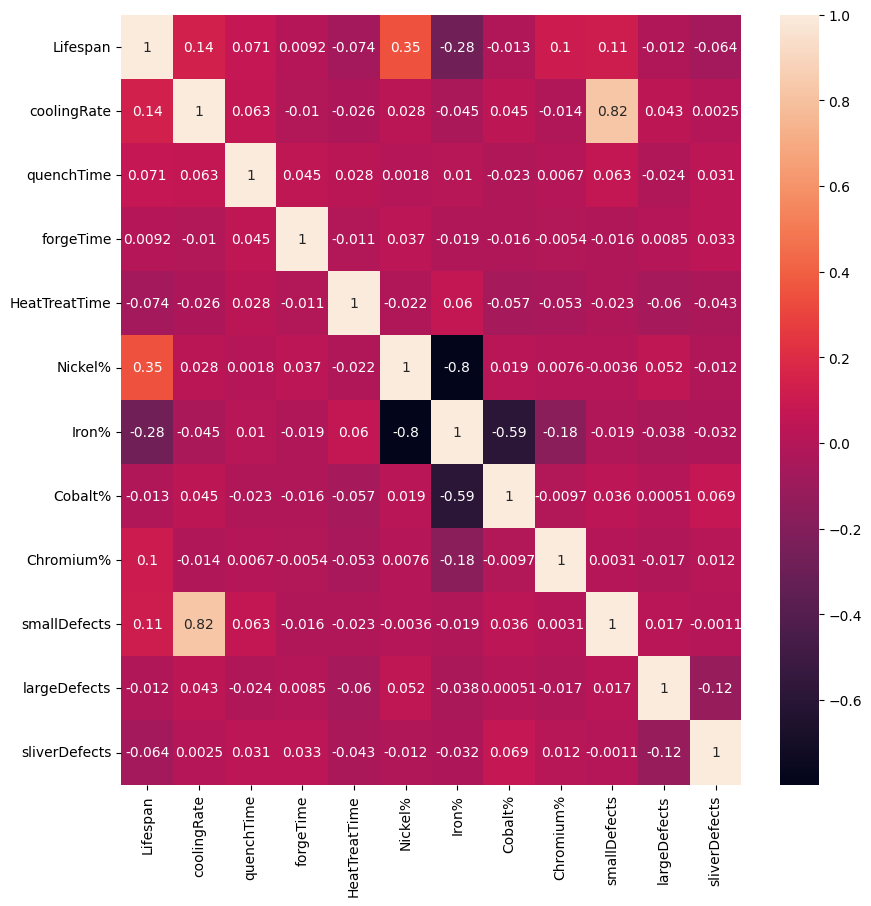

In [ ]:
plt.figure(figsize=(10,10))
sns.heatmap(parts_data[numerical_features].corr(),annot=True)
plt.show()

**Bivariate Analysis(for categorical features)**

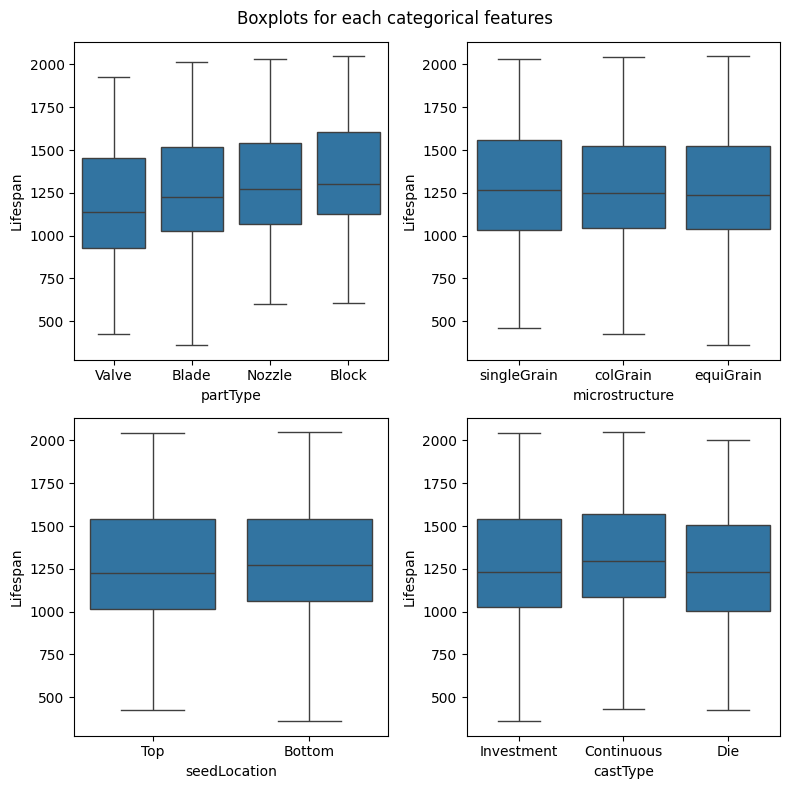

In [ ]:
fig, axes=  plt.subplots(2,2, figsize=(8,8))
axes= axes.flatten()
for i, feature in enumerate(categorical_features):
  sns.boxplot(data= parts_data,x= feature,y='Lifespan',ax= axes[i])
  axes[i].set_xlabel(feature)
plt.suptitle("Boxplots for each categorical features")
plt.tight_layout()
plt.show()

**Multi-variate Analysis**

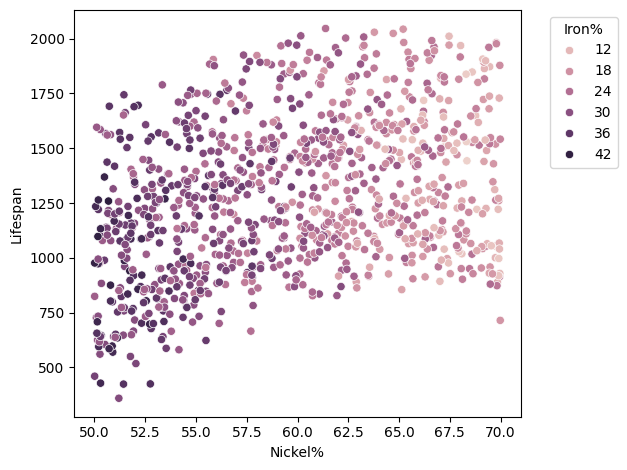

In [ ]:
sns.scatterplot(data=parts_data, x='Nickel%', y='Lifespan', hue='Iron%')
plt.legend(title='Iron%', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

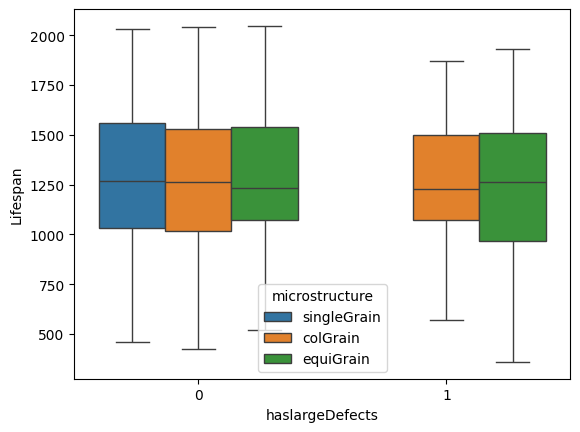

In [ ]:
sns.boxplot(data=parts_data, x='haslargeDefects',y='Lifespan',hue='microstructure')
plt.show()

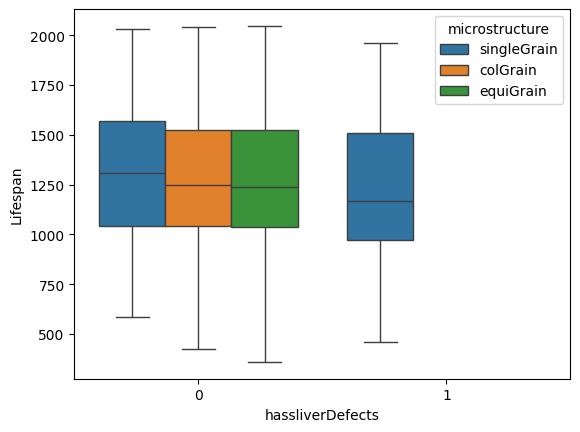

In [ ]:
sns.boxplot(data=parts_data, x='hassliverDefects',y='Lifespan',hue='microstructure')
plt.show()

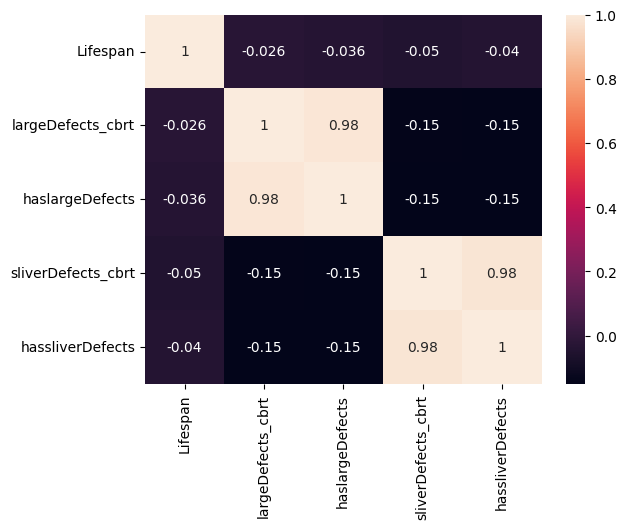

In [ ]:
corr_test_features=['Lifespan','largeDefects_cbrt','haslargeDefects','sliverDefects_cbrt','hassliverDefects']
cor=sns.heatmap(parts_data[corr_test_features].corr(),annot=True)
plt.show()

In [ ]:
print(parts_data['largeDefects'].value_counts())
print(parts_data['sliverDefects'].value_counts())

largeDefects
0    775
1     58
4     58
2     56
3     53
Name: count, dtype: int64
sliverDefects
0    927
3     13
4     12
8     10
7     10
1      9
2      7
6      7
5      5
Name: count, dtype: int64


**Feature Engineering**

In [ ]:
print(parts_data.head())

   Lifespan partType microstructure  coolingRate  quenchTime  forgeTime  \
0   1107.81    Valve    singleGrain           27        2.64       8.08   
1   1226.13    Valve       colGrain           24        4.06       1.11   
2   1914.12    Blade    singleGrain           20        4.36       8.54   
3   1240.83    Valve    singleGrain           14        3.59       8.83   
4   1599.40   Nozzle    singleGrain           22        3.06       3.04   

   HeatTreatTime  Nickel%  Iron%  Cobalt%  ...  seedLocation    castType  \
0          23.35    60.65  19.76    15.18  ...           Top  Investment   
1          24.98    52.47  31.63    12.32  ...           Top  Continuous   
2          34.71    60.98  26.56    11.60  ...        Bottom  Continuous   
3          21.61    54.13  26.71    17.81  ...        Bottom  Continuous   
4          29.65    62.88  24.06    12.08  ...           Top  Investment   

   smallDefects_sqrt  smallDefects_cbrt largeDefects_sqrt largeDefects_cbrt  \
0           2

In [ ]:
test = parts_data.copy()
print(test.head())

   Lifespan partType microstructure  coolingRate  quenchTime  forgeTime  \
0   1107.81    Valve    singleGrain           27        2.64       8.08   
1   1226.13    Valve       colGrain           24        4.06       1.11   
2   1914.12    Blade    singleGrain           20        4.36       8.54   
3   1240.83    Valve    singleGrain           14        3.59       8.83   
4   1599.40   Nozzle    singleGrain           22        3.06       3.04   

   HeatTreatTime  Nickel%  Iron%  Cobalt%  ...  seedLocation    castType  \
0          23.35    60.65  19.76    15.18  ...           Top  Investment   
1          24.98    52.47  31.63    12.32  ...           Top  Continuous   
2          34.71    60.98  26.56    11.60  ...        Bottom  Continuous   
3          21.61    54.13  26.71    17.81  ...        Bottom  Continuous   
4          29.65    62.88  24.06    12.08  ...           Top  Investment   

   smallDefects_sqrt  smallDefects_cbrt largeDefects_sqrt largeDefects_cbrt  \
0           2

In [ ]:
parts_data['Iron_to_Ni%'] = parts_data['Iron%']/parts_data['Nickel%']
print(parts_data['Iron_to_Ni%'].corr(parts_data['Lifespan']))

-0.3275451872418296


In [ ]:
parts_data=parts_data.drop(['smallDefects_sqrt','smallDefects_cbrt','largeDefects','largeDefects_sqrt','sliverDefects','sliverDefects_sqrt','sliverDefects_cbrt','haslargeDefects','hassliverDefects','Iron%','Nickel%'],axis=1)

In [ ]:
print(parts_data.describe())

          Lifespan  coolingRate   quenchTime    forgeTime  HeatTreatTime  \
count  1000.000000  1000.000000  1000.000000  1000.000000    1000.000000   
mean   1281.806120    17.615000     2.693310     5.487040      30.759280   
std     341.136845     7.480156     1.303057     2.604827      17.054664   
min     359.710000     5.000000     0.510000     1.010000       1.050000   
25%    1039.690000    11.000000     1.540000     3.190000      16.387500   
50%    1254.995000    18.000000     2.625000     5.645000      31.560000   
75%    1539.062500    24.000000     3.822500     7.680000      45.655000   
max    2046.410000    30.000000     5.000000     9.970000      59.990000   

           Cobalt%    Chromium%  smallDefects  largeDefects_cbrt  Iron_to_Ni%  
count  1000.000000  1000.000000   1000.000000        1000.000000  1000.000000  
mean     12.416280     2.763990     16.659000           0.297064     0.435526  
std       4.222616     1.307658     11.885874           0.561567     0.1594

In [ ]:
import sklearn
from sklearn.linear_model import Lasso,LinearRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

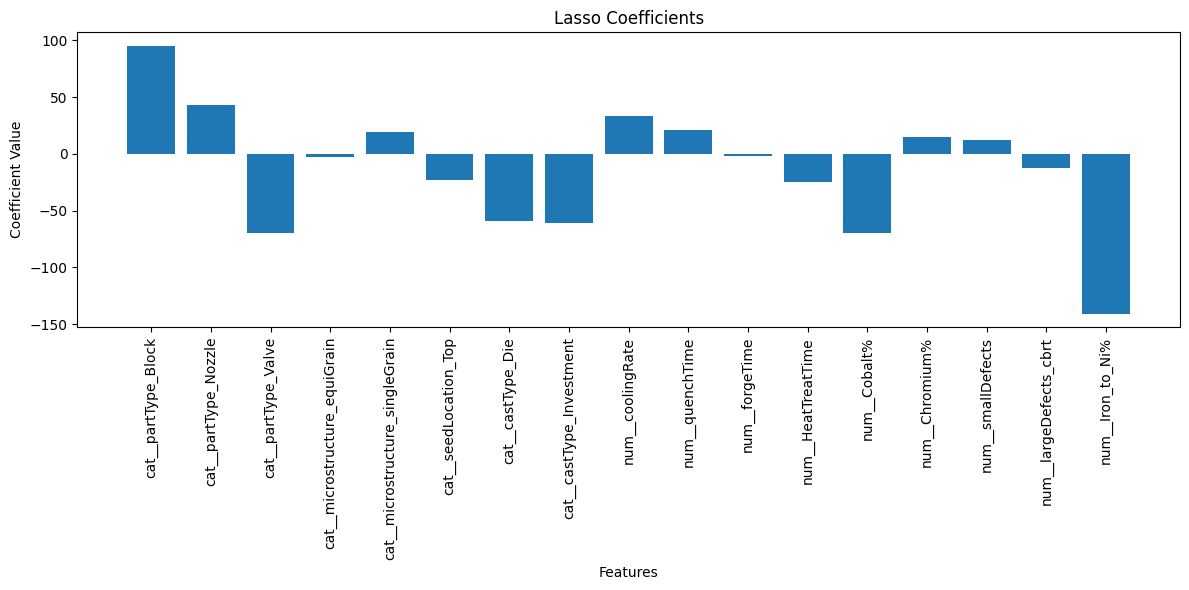

In [ ]:
categorical = ['partType','microstructure','seedLocation','castType']
num=['coolingRate','quenchTime','forgeTime','HeatTreatTime','Cobalt%','Chromium%','smallDefects','largeDefects_cbrt','Iron_to_Ni%']

X = parts_data.drop(columns=['Lifespan'])
y = parts_data['Lifespan']
preprocessing = ColumnTransformer(
    transformers = [
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical),
    ('num', StandardScaler(), num)],
    remainder= 'drop'
)

model =  Pipeline(steps=[
    ('preprocessor', preprocessing),
    ('lassoreg', Lasso(alpha=0.1))
])

model.fit(X,y)
lasso = model.named_steps['lassoreg']
lasso_coef = lasso.coef_

# Get feature names after preprocessing
preprocessor = model.named_steps['preprocessor']
feature_names = preprocessor.get_feature_names_out()

plt.figure(figsize=(12, 6))
plt.bar(feature_names, lasso_coef)
plt.xticks(rotation=90)
plt.title('Lasso Coefficients')
plt.xlabel('Features')
plt.ylabel('Coefficient Value')
plt.tight_layout()
plt.show()

In [ ]:
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lasso.coef_
})

# 6️⃣ Show selected features (non-zero coefficients)
selected = coef_df[coef_df['Coefficient'] != 0]
print(selected.sort_values(by='Coefficient', ascending=False))

                            Feature  Coefficient
0               cat__partType_Block    95.179342
1              cat__partType_Nozzle    42.967456
8                  num__coolingRate    33.367642
9                   num__quenchTime    20.600745
4   cat__microstructure_singleGrain    19.516137
13                   num__Chromium%    14.887659
14                num__smallDefects    12.020084
10                   num__forgeTime    -1.541298
3     cat__microstructure_equiGrain    -2.783780
15           num__largeDefects_cbrt   -12.420486
5             cat__seedLocation_Top   -23.380245
11               num__HeatTreatTime   -24.599739
6                 cat__castType_Die   -58.934997
7          cat__castType_Investment   -61.316660
2               cat__partType_Valve   -69.416851
12                     num__Cobalt%   -70.126875
16                 num__Iron_to_Ni%  -140.891405


In [ ]:
print(parts_data.columns)

Index(['Lifespan', 'partType', 'microstructure', 'coolingRate', 'quenchTime',
       'forgeTime', 'HeatTreatTime', 'Cobalt%', 'Chromium%', 'smallDefects',
       'seedLocation', 'castType', 'largeDefects_cbrt', 'Iron_to_Ni%'],
      dtype='object')


In [ ]:
parts_data=parts_data.drop(['forgeTime'], axis=1)

In [ ]:
print(parts_data.head())

   Lifespan partType microstructure  coolingRate  quenchTime  forgeTime  \
0   1107.81    Valve    singleGrain           27        2.64       8.08   
1   1226.13    Valve       colGrain           24        4.06       1.11   
2   1914.12    Blade    singleGrain           20        4.36       8.54   
3   1240.83    Valve    singleGrain           14        3.59       8.83   
4   1599.40   Nozzle    singleGrain           22        3.06       3.04   

   HeatTreatTime  Cobalt%  Chromium%  smallDefects seedLocation    castType  \
0          23.35    15.18       4.41             7          Top  Investment   
1          24.98    12.32       3.58            30          Top  Continuous   
2          34.71    11.60       0.86            22       Bottom  Continuous   
3          21.61    17.81       1.35            10       Bottom  Continuous   
4          29.65    12.08       0.98            21          Top  Investment   

   largeDefects_cbrt  Iron_to_Ni%  
0                0.0     0.325804  
1 

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, r2_score

SEED=42

In [ ]:
X = parts_data.drop(columns=['Lifespan'])
y = parts_data['Lifespan']
cat=['partType', 'microstructure', 'seedLocation', 'castType']
num=['coolingRate', 'quenchTime', 'HeatTreatTime', 'Cobalt%', 'Chromium%', 'smallDefects', 'largeDefects_cbrt', 'Iron_to_Ni%']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=SEED
)
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat),
        ('num', StandardScaler(), num)
    ],
    remainder='passthrough'
)
model=Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('linreg', LinearRegression())
])
model.fit(X_train, y_train)
y_pred_lin = model.predict(X_test)
rmse_lin = root_mean_squared_error(y_test, y_pred_lin)
r2_lin = r2_score(y_test, y_pred_lin)
print('RMSE score of Linear Regression:', rmse_lin)
print('R2 score of Linear Regression:', r2_lin)


RMSE score of Linear Regression: 300.3937616291066
R2 score of Linear Regression: 0.20588786631349953


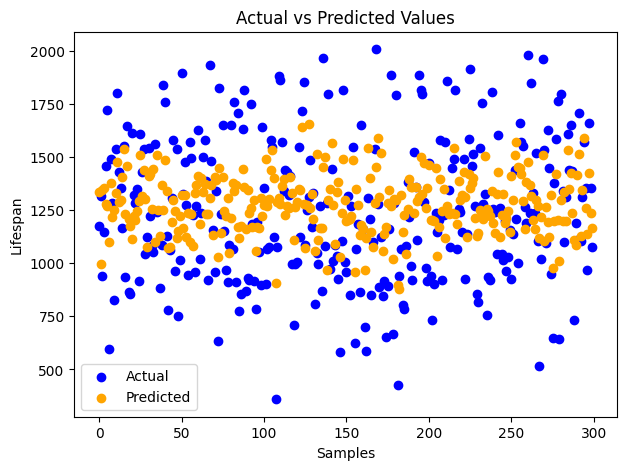

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7,5))
plt.scatter(range(len(y_test)), y_test, label='Actual', color='blue')
plt.scatter(range(len(y_pred_lin)), y_pred_lin, label='Predicted', color='orange')
plt.xlabel("Samples")
plt.ylabel("Lifespan")
plt.title("Actual vs Predicted Values")
plt.legend()
plt.show()


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

rf_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('rf', RandomForestRegressor(random_state=SEED))
])

params_rf = {
    'rf__n_estimators': [200, 250, 300, 350],
    'rf__max_depth': [4, 6, 8],
    'rf__min_samples_leaf': [1, 2, 3],
    'rf__max_features': ['log2', 'sqrt']
}
grid_rf = GridSearchCV(rf_pipe, params_rf, cv=5, scoring='neg_mean_squared_error', verbose=1, n_jobs=-1)
grid_rf.fit(X_train, y_train)
best_hyperparams = grid_rf.best_params_
print("Best Hyperparams: \n", best_hyperparams)
best_model= grid_rf.best_estimator_
y_pred_rf = best_model.predict(X_test)
rmse_rf = root_mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
print(f'RMSE for Random Forest: {rmse_rf:.2f}')
print(f'R2 for Random Forest: {r2_rf:.2f}')

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Hyperparams: 
 {'rf__max_depth': 8, 'rf__max_features': 'log2', 'rf__min_samples_leaf': 1, 'rf__n_estimators': 300}
RMSE for Random Forest: 158.70314160194215
R2 for Random Forest: 0.7783483027791126


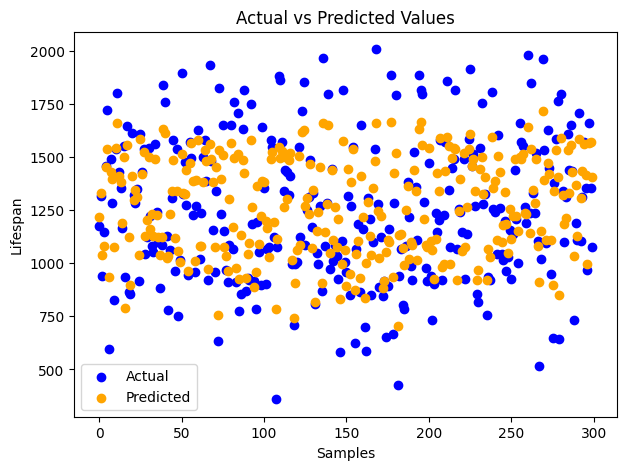

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7,5))
plt.scatter(range(len(y_test)), y_test, label='Actual', color='blue')
plt.scatter(range(len(y_pred_rf)), y_pred_rf, label='Predicted', color='orange')
plt.xlabel("Samples")
plt.ylabel("Lifespan")
plt.title("Actual vs Predicted Values")
plt.legend()
plt.show()



In [ ]:
results = pd.DataFrame(grid_rf.cv_results_)
print(results.sort_values(by='rank_test_score').head(5))

    mean_fit_time  std_fit_time  mean_score_time  std_score_time  \
50       1.145450      0.041690         0.071014        0.015334   
62       1.745242      0.289060         0.107074        0.018465   
60       0.732124      0.020121         0.046952        0.003126   
48       0.742032      0.021182         0.045061        0.001231   
51       1.626628      0.320522         0.117044        0.035573   

    param_rf__max_depth param_rf__max_features  param_rf__min_samples_leaf  \
50                    8                   log2                           1   
62                    8                   sqrt                           1   
60                    8                   sqrt                           1   
48                    8                   log2                           1   
51                    8                   log2                           1   

    param_rf__n_estimators                                             params  \
50                     300  {'rf__max_dep

In [ ]:
results[['params', 'mean_test_score', 'std_test_score']].sort_values(
    by='mean_test_score', ascending=False
).head(5)


,params,mean_test_score,std_test_score
50,"{'rf__max_depth': 8, 'rf__max_features': 'log2...",-26572.831970,3291.830076
62,"{'rf__max_depth': 8, 'rf__max_features': 'sqrt...",-26572.831970,3291.830076
60,"{'rf__max_depth': 8, 'rf__max_features': 'sqrt...",-26574.687364,3096.421228
48,"{'rf__max_depth': 8, 'rf__max_features': 'log2...",-26574.687364,3096.421228
51,"{'rf__max_depth': 8, 'rf__max_features': 'log2...",-26732.263649,3121.914405


In [ ]:
!pip install keras_tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 5.0 MB/s eta 0:00:00


In [ ]:
import tensorflow as tf
import keras
import keras_tuner as kt
from tensorflow.keras import layers

keras.utils.set_random_seed(SEED)


In [ ]:
X_train_pre =  preprocessor.fit_transform(X_train)
X_test_pre = preprocessor.transform(X_test)
input_dim=X_train_pre.shape[1]

def mlp_tuner(hp):
  model= keras.Sequential()
  model.add(layers.Input(shape=(input_dim,)))

  for i in range(hp.Int('num_layers', 1, 4)):
    model.add(layers.Dense(units=hp.Int(f'units_{i}', min_value=32, max_value=512, step=32), activation='relu'))
    model.add(layers.Dropout(hp.Float(f'dropout_{i}', min_value=0.0, max_value=0.5, step=0.1)))

  model.add(layers.Dense(1,activation='linear'))

  hp_lr=hp.Choice('learning_rate', values=[0.001, 0.01, 0.1])
  model.compile(optimizer=keras.optimizers.Adam(learning_rate=hp_lr), loss='mse', metrics=[keras.metrics.RootMeanSquaredError()])
  return model

tuner = kt.Hyperband(
    mlp_tuner,
    objective='val_root_mean_squared_error',
    max_epochs=50,
    factor=3,
    directory='kt_dir1',
    project_name='kt_lifespan_reg'
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_root_mean_squared_error', patience=10, restore_best_weights=True)
]

tuner.search(X_train_pre, y_train, epochs=20, validation_split=0.2, callbacks=callbacks, verbose=1)

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print("\nBest Hyperparameters:")
for param, value in best_hps.values.items():
    print(f"{param}: {value}")

best_model = tuner.get_best_models(num_models=1)[0]

nn_pred = best_model.predict(X_test_pre)
nn_rmse = root_mean_squared_error(y_test, nn_pred)
nn_r2 = r2_score(y_test, nn_pred)
print('rmse:', nn_rmse)
print('r2:', nn_r2)

Reloading Tuner from kt_dir1/kt_lifespan_reg/tuner0.json

Best Hyperparameters:
num_layers: 4
units_0: 192
dropout_0: 0.0
learning_rate: 0.01
units_1: 384
dropout_1: 0.1
units_2: 512
dropout_2: 0.2
units_3: 352
dropout_3: 0.1
tuner/epochs: 50
tuner/initial_epoch: 0
tuner/bracket: 0
tuner/round: 0
 1/10 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
rmse: 147.82051335233177
r2: 0.8077043652102467


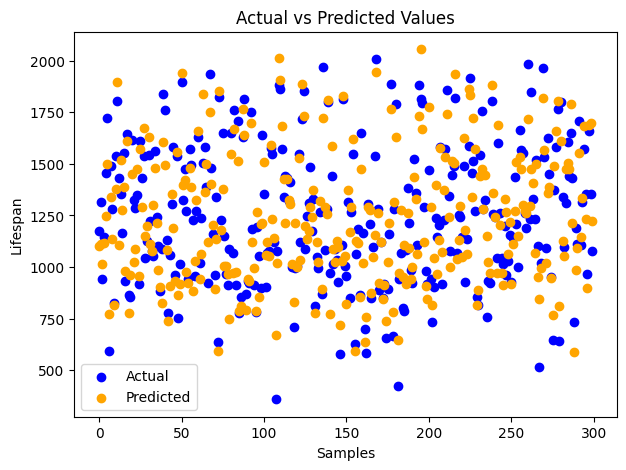

In [ ]:
# Retrain the model with the best hyperparameters
import random
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

plt.figure(figsize=(7,5))
plt.scatter(range(len(y_test)), y_test, label='Actual', color='blue')
plt.scatter(range(len(nn_pred)), nn_pred, label='Predicted', color='orange')
plt.xlabel("Samples")
plt.ylabel("Lifespan")
plt.title("Actual vs Predicted Values")
plt.legend()
plt.show()


# **Classification**

k=3, silhouette score=0.4977
k=4, silhouette score=0.5075
k=5, silhouette score=0.4968


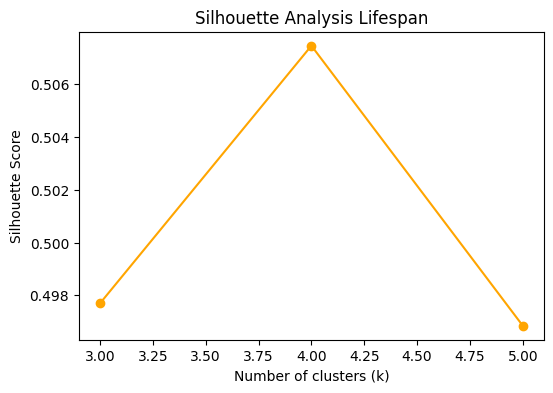

In [ ]:
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering

X_life = parts_data[['Lifespan']]

silhouette_scores = []

for k in range(3, 6):
    ac = AgglomerativeClustering(n_clusters=k,linkage='ward')
    labels = ac.fit_predict(X_life)
    score = silhouette_score(X_life, labels)
    silhouette_scores.append(score)
    print(f"k={k}, silhouette score={score:.4f}")

# Visualize silhouette scores
plt.figure(figsize=(6, 4))
plt.plot(range(3, 6), silhouette_scores, marker='o', color='orange')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis Lifespan')
plt.show()


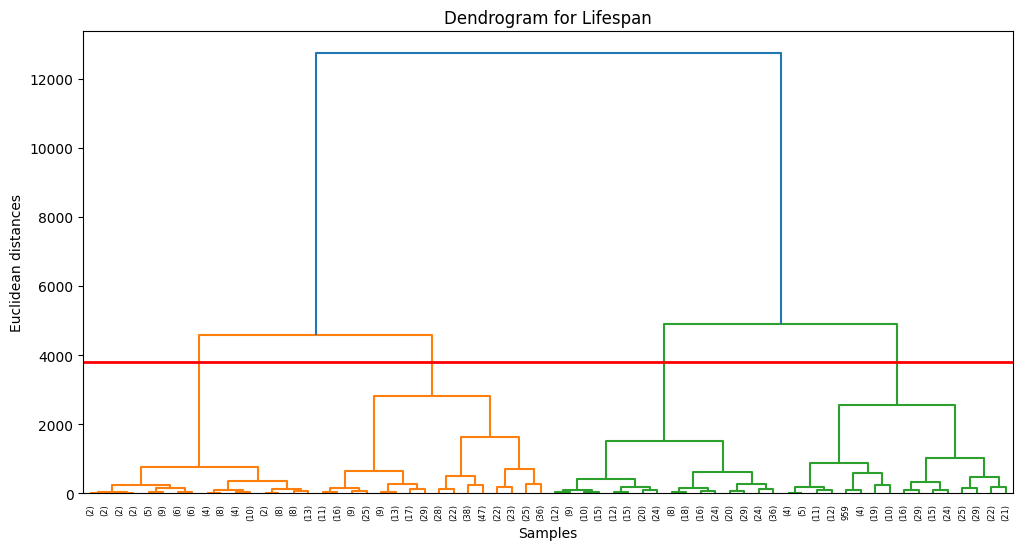

In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import matplotlib.pyplot as plt

# Hierarchical clustering
Z = linkage(X_life, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode='level', p=5)
plt.title('Dendrogram for Lifespan')
plt.xlabel('Samples')
plt.ylabel('Euclidean distances')
cut_height = 3800
plt.axhline(y=cut_height, color='red', linestyle='-', linewidth=2)

plt.show()

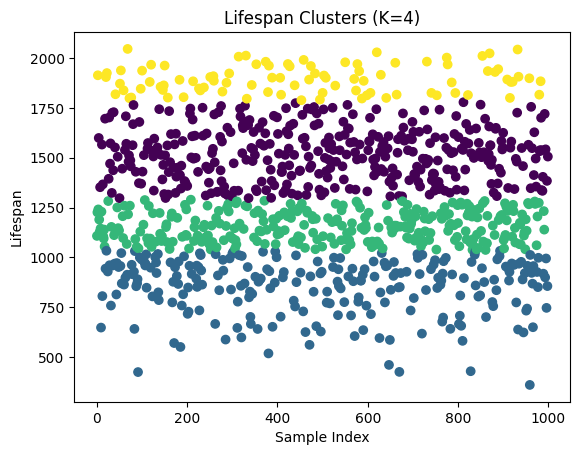

In [ ]:
ag = AgglomerativeClustering(n_clusters=4, linkage='ward')
parts_data['life_cluster'] = ag.fit_predict(X_life)
plt.scatter(parts_data.index, parts_data['Lifespan'], c=parts_data['life_cluster'], cmap='viridis')
plt.xlabel('Sample Index')
plt.ylabel('Lifespan')
plt.title('Lifespan Clusters (K=4)')
plt.show()

In [ ]:
mapping = {0:'Normal', 1:'Premature', 2:'At Risk', 3:'Well Maintained'}
parts_data['life_Category'] = parts_data['life_cluster'].map(mapping)

In [ ]:
print(parts_data.head())

   Lifespan partType microstructure  coolingRate  quenchTime  HeatTreatTime  \
0   1107.81    Valve    singleGrain           27        2.64          23.35   
1   1226.13    Valve       colGrain           24        4.06          24.98   
2   1914.12    Blade    singleGrain           20        4.36          34.71   
3   1240.83    Valve    singleGrain           14        3.59          21.61   
4   1599.40   Nozzle    singleGrain           22        3.06          29.65   

   Cobalt%  Chromium%  smallDefects seedLocation    castType  \
0    15.18       4.41             7          Top  Investment   
1    12.32       3.58            30          Top  Continuous   
2    11.60       0.86            22       Bottom  Continuous   
3    17.81       1.35            10       Bottom  Continuous   
4    12.08       0.98            21          Top  Investment   

   largeDefects_cbrt  Iron_to_Ni%  life_cluster    life_Category  
0                0.0     0.325804             2          At Risk  
1     

In [ ]:
parts_data['Lifespan'].groupby(parts_data['life_Category']).mean().sort_values()

,Lifespan
life_Category,
Premature,856.130040
At Risk,1156.025582
Normal,1514.533162
Well Maintained,1894.563297


In [ ]:
parts_data.groupby('life_Category')['Lifespan'].agg(['min', 'max', 'mean']).sort_values(by='mean')

,min,max,mean
life_Category,,,
Premature,359.71,1033.27,856.130040
At Risk,1037.22,1289.67,1156.025582
Normal,1297.34,1778.86,1514.533162
Well Maintained,1789.25,2046.41,1894.563297


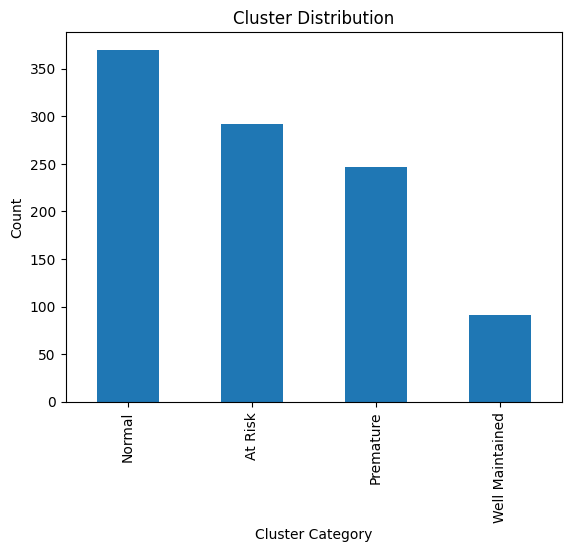

In [ ]:
parts_data['life_Category'].value_counts().plot(kind='bar')
plt.title("Cluster Distribution")
plt.xlabel("Cluster Category")
plt.ylabel("Count")
plt.show()

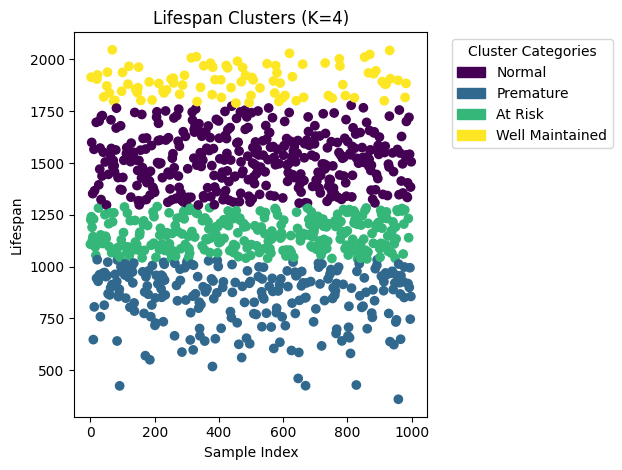

In [ ]:
import matplotlib.patches as mpatches

# Scatter plot
plt.scatter(
    parts_data.index,
    parts_data['Lifespan'],
    c=parts_data['life_cluster'],
    cmap='viridis'
)

plt.xlabel('Sample Index')
plt.ylabel('Lifespan')
plt.title('Lifespan Clusters (K=4)')

# --- Create legend manually ---
legend_patches = []
unique_clusters = sorted(parts_data['life_cluster'].unique())

# get the colormap
cmap = plt.cm.viridis

for cluster_id in unique_clusters:
    color = cmap(cluster_id / (len(unique_clusters)-1))  # normalize colormap
    label = mapping[cluster_id]
    patch = mpatches.Patch(color=color, label=f"{label}")
    legend_patches.append(patch)

plt.legend(handles=legend_patches, title="Cluster Categories", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


In [ ]:
print(parts_data.head())

   Lifespan partType microstructure  coolingRate  quenchTime  forgeTime  \
0   1107.81    Valve    singleGrain           27        2.64       8.08   
1   1226.13    Valve       colGrain           24        4.06       1.11   
2   1914.12    Blade    singleGrain           20        4.36       8.54   
3   1240.83    Valve    singleGrain           14        3.59       8.83   
4   1599.40   Nozzle    singleGrain           22        3.06       3.04   

   HeatTreatTime  Cobalt%  Chromium%  smallDefects seedLocation    castType  \
0          23.35    15.18       4.41             7          Top  Investment   
1          24.98    12.32       3.58            30          Top  Continuous   
2          34.71    11.60       0.86            22       Bottom  Continuous   
3          21.61    17.81       1.35            10       Bottom  Continuous   
4          29.65    12.08       0.98            21          Top  Investment   

   largeDefects_cbrt  Iron_to_Ni%  life_cluster  
0                0.0    

Random Baseline Classification Report:

              precision    recall  f1-score   support

           0       0.39      0.26      0.31       111
           1       0.19      0.18      0.18        74
           2       0.23      0.20      0.22        88
           3       0.07      0.22      0.11        27

    accuracy                           0.22       300
   macro avg       0.22      0.22      0.21       300
weighted avg       0.27      0.22      0.24       300



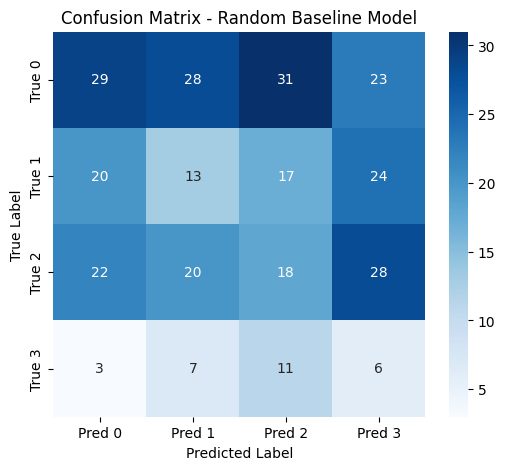

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
X = parts_data.drop(columns=['Lifespan','life_cluster','life_Category'])
y = parts_data['life_cluster']
X_train,X_test, y_train, y_test = train_test_split(X, y, stratify = y, test_size=0.3, random_state=SEED)
np.random.seed(SEED)
unique_labels = np.sort(y_train.unique())
y_pred_random = np.random.choice(unique_labels, size=len(y_test))
print("Random Baseline Classification Report:\n")
print(classification_report(y_test, y_pred_random, digits=2))
cm = confusion_matrix(y_test, y_pred_random, labels = unique_labels)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f'Pred {l}' for l in unique_labels],
            yticklabels=[f'True {l}' for l in unique_labels])

plt.title("Confusion Matrix - Random Baseline Model")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

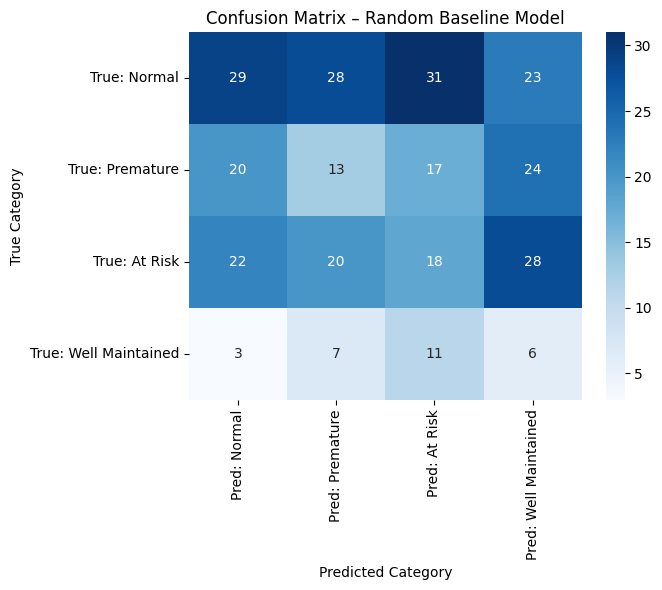

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Convert numerical labels to category names
true_names = [mapping[l] for l in y_test]
pred_names = [mapping[l] for l in y_pred_random]

# Compute confusion matrix using category names
unique_categories = list(mapping.values())
cm = confusion_matrix(true_names, pred_names, labels=unique_categories)

# Plot
plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[f"Pred: {c}" for c in unique_categories],
    yticklabels=[f"True: {c}" for c in unique_categories]
)

plt.title("Confusion Matrix – Random Baseline Model")
plt.xlabel("Predicted Category")
plt.ylabel("True Category")
plt.tight_layout()
plt.show()


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Classification Report:
               precision    recall  f1-score   support

           0       0.42      0.66      0.51       111
           1       0.45      0.47      0.46        74
           2       0.36      0.18      0.24        88
           3       0.33      0.04      0.07        27

    accuracy                           0.42       300
   macro avg       0.39      0.34      0.32       300
weighted avg       0.40      0.42      0.38       300



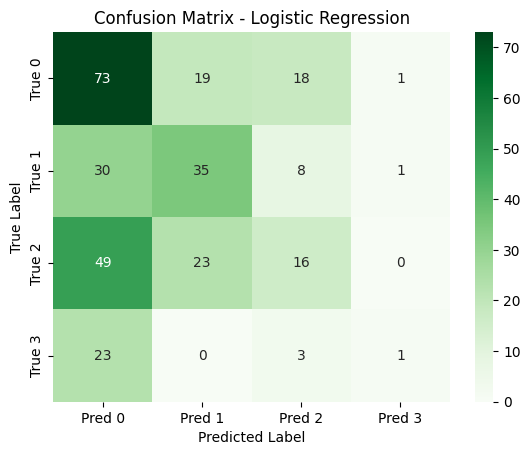

In [ ]:
from sklearn.linear_model import LogisticRegression
preprocessor_class = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat),
        ('num', StandardScaler(), num)
    ],
    remainder='passthrough'
)
logreg_pipeline=Pipeline(steps=[
    ('preprocessor_class', preprocessor_class),
    ('logreg', LogisticRegression(max_iter=1000, multi_class='multinomial', random_state=SEED))
])
logreg_pipeline.fit(X_train, y_train)
y_pred_log = logreg_pipeline.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred_log))

# Confusion Matrix
unique_labels = np.sort(y.unique())
cm = confusion_matrix(y_test, y_pred_log, labels=unique_labels)
cm_df = pd.DataFrame(cm,
                     index=[f"True {l}" for l in unique_labels],
                     columns=[f"Pred {l}" for l in unique_labels])
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

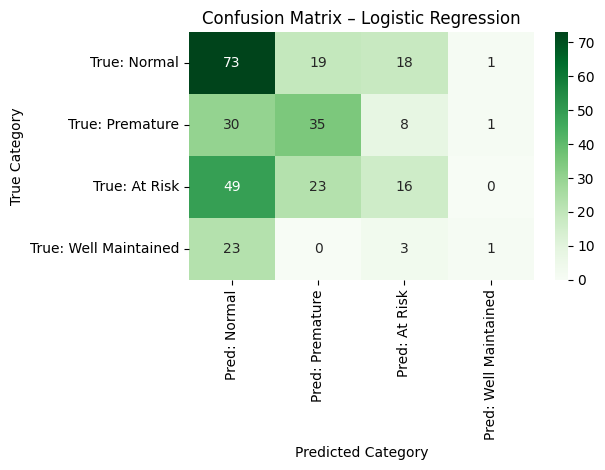

In [ ]:
# Convert numerical labels to category names
true_names = [mapping[l] for l in y_test]
pred_names = [mapping[l] for l in y_pred_log]

# Compute confusion matrix using category names
unique_categories = list(mapping.values())
cm = confusion_matrix(true_names, pred_names, labels=unique_categories)

# Plot
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=[f"Pred: {c}" for c in unique_categories],
    yticklabels=[f"True: {c}" for c in unique_categories]
)

plt.title("Confusion Matrix – Logistic Regression")
plt.xlabel("Predicted Category")
plt.ylabel("True Category")
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Best Parameters: {'logreg__C': np.float64(0.112), 'logreg__solver': 'newton-cg'}
Classification Report:
               precision    recall  f1-score   support

           0       0.42      0.67      0.51       111
           1       0.45      0.47      0.46        74
           2       0.37      0.18      0.24        88
           3       0.50      0.04      0.07        27

    accuracy                           0.42       300
   macro avg       0.44      0.34      0.32       300
weighted avg       0.42      0.42      0.38       300



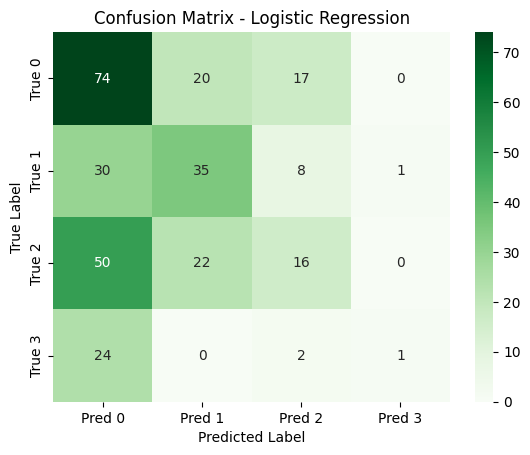

In [ ]:
from sklearn.model_selection import GridSearchCV,KFold
params = {
    "logreg__C": np.linspace(0.001, 1.0, 10),
    "logreg__solver": ["newton-cg", "saga", "lbfgs"]
}
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
tuning =  GridSearchCV(logreg_pipeline, param_grid = params, scoring = 'accuracy', cv=kf, n_jobs=-1)
tuning.fit(X_train, y_train)
print("Best Parameters:", tuning.best_params_)
best_logreg = tuning.best_estimator_
y_pred_best = best_logreg.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred_best))
# Confusion Matrix
unique_labels = np.sort(y.unique())
cm = confusion_matrix(y_test, y_pred_best, labels=unique_labels)
cm_df = pd.DataFrame(cm,
                     index=[f"True {l}" for l in unique_labels],
                     columns=[f"Pred {l}" for l in unique_labels])
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

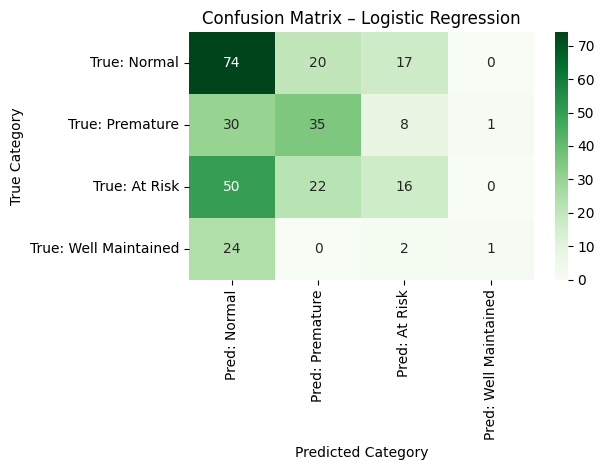

In [ ]:
# Convert numerical labels to category names
true_names = [mapping[l] for l in y_test]
pred_names = [mapping[l] for l in y_pred_best]

# Compute confusion matrix using category names
unique_categories = list(mapping.values())
cm = confusion_matrix(true_names, pred_names, labels=unique_categories)

# Plot
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=[f"Pred: {c}" for c in unique_categories],
    yticklabels=[f"True: {c}" for c in unique_categories]
)

plt.title("Confusion Matrix – Logistic Regression")
plt.xlabel("Predicted Category")
plt.ylabel("True Category")
plt.tight_layout()
plt.show()

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Parameters: {'rf__max_depth': None, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 1, 'rf__n_estimators': 100}
Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.94      0.78       111
           1       0.88      0.76      0.81        74
           2       0.66      0.55      0.60        88
           3       1.00      0.26      0.41        27

    accuracy                           0.72       300
   macro avg       0.80      0.62      0.65       300
weighted avg       0.75      0.72      0.70       300



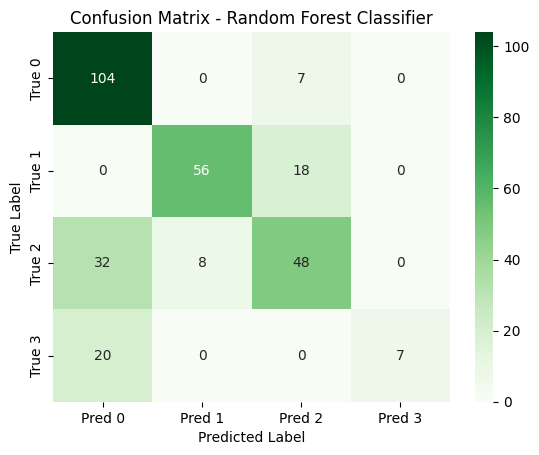

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, KFold

rf_pipeline = Pipeline(steps=[
    ('preprocessor_class', preprocessor_class),
    ('rf', RandomForestClassifier(random_state=SEED))
])
param_grid = {
    "rf__n_estimators": [100, 200, 300],
    "rf__max_depth": [None, 10, 20, 30],
    "rf__min_samples_leaf": [1, 2, 4],
    "rf__max_features": ["sqrt", "log2"]
}
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
grid_rf = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=kf,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)
grid_rf.fit(X_train, y_train)
print("Best Parameters:", grid_rf.best_params_)
best_rf = grid_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred_rf))
# Confusion Matrix
unique_labels = np.sort(y.unique())
cm = confusion_matrix(y_test, y_pred_rf, labels=unique_labels)
cm_df = pd.DataFrame(cm,
                     index=[f"True {l}" for l in unique_labels],
                     columns=[f"Pred {l}" for l in unique_labels])
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Random Forest Classifier")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

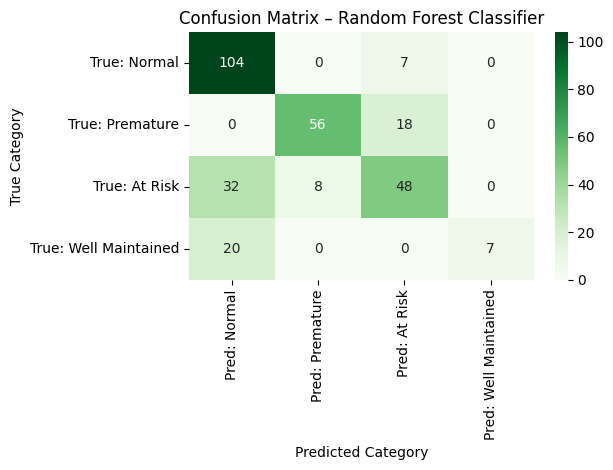

In [ ]:
# Convert numerical labels to category names
true_names = [mapping[l] for l in y_test]
pred_names = [mapping[l] for l in y_pred_rf]

# Compute confusion matrix using category names
unique_categories = list(mapping.values())
cm = confusion_matrix(true_names, pred_names, labels=unique_categories)

# Plot
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=[f"Pred: {c}" for c in unique_categories],
    yticklabels=[f"True: {c}" for c in unique_categories]
)

plt.title("Confusion Matrix – Random Forest Classifier")
plt.xlabel("Predicted Category")
plt.ylabel("True Category")
plt.tight_layout()
plt.show()